# Predicting Patient Outcome from AMR Profiles 

Here, we will analyze clinical data from AMR reports.

Unfortunately, true reports are not really accessible, so we will synthesize one from a dataframe version of lab reports from bacterial isolates from Bangladesh

In the end, we want to be able to predict patient outcome (ICU vs Recovered) based on the resistance profile of the bug, without even knowing the bug itself

*REF: siam, Morsalin sarker; Faiza, Ariya Tasnim (2025), “Antibiotic Resistance Tracking Dataset ”, Mendeley Data, V2, doi: 10.17632/h4byb28gcv.2*

### Install XGBoost and load libraries

In [25]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

from xgboost import XGBClassifier

### Load the AMR Dataset

In [56]:
amr_source = 'https://raw.githubusercontent.com/HackBio-Internship/2025_project_collection/refs/heads/main/antibiotic_resistance_tracking.csv'
amr = pd.read_csv(amr_source)

In [57]:
amr.head()

,Patient_ID,Age,Gender,Specimen_Type,Amoxicillin,Ciprofloxacin,Meropenem,Vancomycin,Colistin,Test_Method,Resistance_Genes,Outcome
0,P0001,36,Female,Blood,Intermediate,Sensitive,Intermediate,Intermediate,Intermediate,Automated System,KPC,ICU
1,P0002,59,Female,Blood,Intermediate,Resistant,Intermediate,Sensitive,Intermediate,MIC,KPC,Recovered
2,P0003,13,Female,Urine,Intermediate,Sensitive,Resistant,Intermediate,Resistant,MIC,OXA-48,ICU
3,P0004,4,Female,Sputum,Intermediate,Resistant,Sensitive,Intermediate,Intermediate,Automated System,OXA-48,ICU
4,P0005,51,Male,Urine,Resistant,Sensitive,Resistant,Intermediate,Intermediate,Automated System,NaN,ICU


Identify your key columns

- specimen (e.g., sample_source, specimen)
- antibiotic (e.g., antibiotic)
- interpretation/outcome (e.g., susceptibility, result) with values like S/I/R

### Cleaning the dataset

We will use only ICU vs recovered in this case

<Axes: xlabel='count', ylabel='Outcome'>

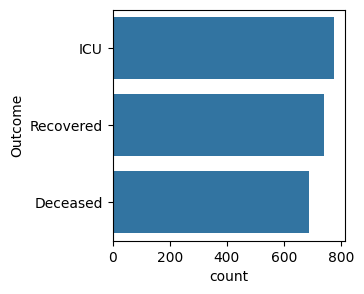

In [58]:
plt.figure(figsize=(3,3))
sns.countplot(amr["Outcome"])

In [59]:
amr["Outcome"].value_counts()

Outcome
ICU          775
Recovered    739
Deceased     686
Name: count, dtype: int64

In [60]:
amr = amr[amr["Outcome"].isin(["ICU", "Recovered"])].copy()

amr["y"] = (amr["Outcome"] == "ICU").astype(int)

amr["y"].value_counts()

y
1    775
0    739
Name: count, dtype: int64

✅ ICU = 1

✅ Recovered = 0

🧠 Important Clinical Note

We are asking:

Does resistance severity correlate with worse outcomes?

This is a prognostic model, not a diagnostic one.

### Select Predictors

In [62]:
features = [
    "Age",
    "Gender",
    "Specimen_Type",
    "Test_Method",
    "Resistance_Genes",
    "Amoxicillin",
    "Ciprofloxacin",
    "Meropenem",
    "Vancomycin",
    "Colistin"
]

X = amr[features].copy()
y = amr["y"]

In [63]:
amr.head(2)

,Patient_ID,Age,Gender,Specimen_Type,Amoxicillin,Ciprofloxacin,Meropenem,Vancomycin,Colistin,Test_Method,Resistance_Genes,Outcome,y
0,P0001,36,Female,Blood,Intermediate,Sensitive,Intermediate,Intermediate,Intermediate,Automated System,KPC,ICU,1
1,P0002,59,Female,Blood,Intermediate,Resistant,Intermediate,Sensitive,Intermediate,MIC,KPC,Recovered,0


### Encode Categorical Variables

In [64]:
categorical_cols = X.select_dtypes(include="object").columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [66]:
X.head()

,Age,Gender,Specimen_Type,Test_Method,Resistance_Genes,Amoxicillin,Ciprofloxacin,Meropenem,Vancomycin,Colistin
0,36,0,0,0,0,0,2,0,0,0
1,59,0,0,2,0,0,1,0,2,0
2,13,0,3,2,2,0,2,1,0,1
3,4,0,1,0,2,0,1,2,0,0
4,51,1,3,0,4,1,2,1,0,0


### Train/Test Split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### Evaluate Model Performance

In [71]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       148
           1       0.51      1.00      0.68       155

    accuracy                           0.51       303
   macro avg       0.26      0.50      0.34       303
weighted avg       0.26      0.51      0.35       303

ROC AUC: 0.5105492589363557


/Users/josoga2/Documents/wale_docs/phd/HB/py/hb_ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/josoga2/Documents/wale_docs/phd/HB/py/hb_ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/josoga2/Documents/wale_docs/phd/HB/py/hb_ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha